# News Event Clustering and Summarization Pipeline


**Objective:** Group news articles into distinct real-world events using unsupervised embedding-based clustering, generate descriptive event labels, and produce automated event summaries using LLM-based and transformer-based (BART) text generation.

**Pipeline Stages:**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Data Loading & Setup | Import libraries and load the raw news dataset |
| 2 | Data Cleaning | Handle missing values, duplicates, and data types |
| 3 | Exploratory Data Analysis | Understand category distribution and publishing trends |
| 4 | Feature Engineering | Prepare combined text field for embedding |
| 5 | Text Embedding Generation | Generate sentence embeddings using Sentence-Transformers |
| 6 | Event Clustering | Reduce dimensionality (UMAP) and cluster (HDBSCAN) |
| 7 | Cluster Labeling | Extract keywords (TF-IDF) and representative headlines |
| 8 | Event Table Construction | Aggregate clusters into a structured event-level table |
| 9 | Event Analysis & Visualization | Analyze event size, duration, and keyword trends |
| 10 | Automated Event Summarization | Generate event summaries using an LLM (Gemini) and BART |
| 11 | Final Output Generation & Export | Compile and export the final summarized event dataset |

---


## 1. Data Loading & Setup

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load Dataset

In [ ]:
df = pd.read_json('/content/drive/MyDrive/News_Category_Dataset_v3.json', lines=True)

In [ ]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',10)

## 2. Data Cleaning

### 2.1 Initial Data Inspection

In [ ]:
df.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

In [ ]:
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlines-passenger-banned-flight-attendant-punch-justice-department_n_632e25d3e4b0e247890329fe,"American Airlines Flyer Charged, Banned For Life After Punching Flight Attendant On Video",U.S. NEWS,"He was subdued by passengers and crew when he fled to the back of the aircraft after the confrontation, according to the U.S. attorney's office in Los Angeles.",Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets-cats-dogs-september-17-23_n_632de332e4b0695c1d81dc02,23 Of The Funniest Tweets About Cats And Dogs This Week (Sept. 17-23),COMEDY,"""Until you have a dog you don't understand what could be eaten.""",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parenting-tweets_l_632d7d15e4b0d12b5403e479,The Funniest Tweets From Parents This Week (Sept. 17-23),PARENTING,"""Accidentally put grown-up toothpaste on my toddler’s toothbrush and he screamed like I was cleaning his teeth with a Carolina Reaper dipped in Tabasco sauce.""",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-loses-discrimination-lawsuit-franklin-templeton_n_632c6463e4b09d8701bd227e,Woman Who Called Cops On Black Bird-Watcher Loses Lawsuit Against Ex-Employer,U.S. NEWS,Amy Cooper accused investment firm Franklin Templeton of unfairly firing her and branding her a racist after video of the Central Park encounter went viral.,Nina Golgowski,2022-09-22


In [ ]:
df.tail()

,link,headline,category,short_description,authors,date
209522,https://www.huffingtonpost.com/entry/rim-ceo-thorsten-heins_us_5bb34b8ce4b0fa920b95c4e1,RIM CEO Thorsten Heins' 'Significant' Plans For BlackBerry,TECH,Verizon Wireless and AT&T are already promoting LTE devices including smartphones and tablets from RIM's rivals. RIM's first,"Reuters, Reuters",2012-01-28
209523,https://www.huffingtonpost.com/entry/maria-sharapova-stunned-victoria-azarenka-australian-open_us_5bb69b21e4b097869fd1b2f1,Maria Sharapova Stunned By Victoria Azarenka In Australian Open Final,SPORTS,"Afterward, Azarenka, more effusive with the press than normal, credited her coach of two years, Sam Sumyk, for his patient",,2012-01-28
209524,https://www.huffingtonpost.com/entry/super-bowl-upsets-the-mos_us_5bb69b1de4b097869fd1b26d,"Giants Over Patriots, Jets Over Colts Among Most Improbable Super Bowl Upsets Of All Time (VIDEOS)",SPORTS,"Leading up to Super Bowl XLVI, the most talked about game could end up being one that occurred a few years ago. After all",,2012-01-28
209525,https://www.huffingtonpost.com/entry/aldon-smith-arrested-dui-49ers_us_5bb69b25e4b097869fd1b33c,Aldon Smith Arrested: 49ers Linebacker Busted For DUI,SPORTS,CORRECTION: An earlier version of this story incorrectly stated the location of KTVU and the 2011 league leader in sacks,,2012-01-28
209526,https://www.huffingtonpost.com/entry/dwight-howard-rips-teammates-magic-hornets_us_5bb69b24e4b097869fd1b331,Dwight Howard Rips Teammates After Magic Loss To Hornets,SPORTS,The five-time all-star center tore into his teammates Friday night after Orlando committed 23 turnovers en route to losing,,2012-01-28


### 2.2 Handling Missing Values

In [ ]:
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


lots of values are empty string which we can concluse as null values

In [ ]:
df = df.replace('',np.nan)

In [ ]:
(df.isnull().sum() / df.shape[0])*100

,0
link,0.000000
headline,0.002864
category,0.000000
short_description,9.407857
authors,17.858319
date,0.000000


we will fill missing authors name as unknown

In [ ]:
df['authors'] = df['authors'].fillna('Unknown')

In [ ]:
df[df['short_description'].isnull()].head()

,link,headline,category,short_description,authors,date
20773,https://www.huffingtonpost.com/entry/the-big-blue-wave_us_5a050838e4b0ee8ec3694054,The Big Blue Wave,COMEDY,NaN,"Shan Wells, ContributorSciency sun venerator + cartoons",2017-11-10
21523,https://www.huffingtonpost.com/entry/inside-rukban-camp-one-of-syrias-most-desperate-settlements_us_59f87fd8e4b0aec1467ace64,"Inside Rukban Camp, One Of Syria’s Most Desperate Settlements",WORLD NEWS,NaN,"Yasser Allawi, Syria Deeply",2017-10-31
22793,https://www.huffingtonpost.com/entry/syrian-refugees-return-from-lebanon-only-to-flee-war-yet-again_us_59e263d6e4b03a7be580fff6,Syrian Refugees Return From Lebanon Only To Flee War Yet Again,WORLD NEWS,NaN,"Abby Sewell, Refugees Deeply",2017-10-14
32223,https://www.huffingtonpost.com/entry/your-guide-to-the-best-bbq-in-st-louis_us_594806e8e4b0cddbb0088011,Your Guide To The Best BBQ In St. Louis According to Zagat,TASTE,NaN,Unknown,2017-06-19
34488,https://www.huffingtonpost.com/entry/the-bechdel-test_us_5925be6be4b0dfb1ca3a106a,The Bechdel Test,COMEDY,NaN,"Hilary Fitzgerald Campbell, ContributorHilary's cartoons have appeared in The New Yorker and other fu...",2017-05-24


In [ ]:
df['short_description'] = df['short_description'].fillna(df['headline']) #filling null values with headline

In [ ]:
df.isnull().sum()

,0
link,0
headline,6
category,0
short_description,5
authors,0
date,0


there are some null values headline as well as short description so that why it became null

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


### 2.3 Handling Duplicate Records

In [ ]:
has_duplicates = df.duplicated().any()
print(has_duplicates)

True


In [ ]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

13


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.sample(10)

,link,headline,category,short_description,authors,date
5566,https://www.huffpost.com/entry/beto-orourke-helping-texas-democrats-flip-state-house_n_5e000a53e4b0b2520d0ceb83,Beto O'Rourke's Next Move? Helping Texas Democrats Flip The State House,POLITICS,The former presidential candidate announced a new political action committee meant to help Democrats take control of the Texas House.,Sanjana Karanth,2019-12-23
119134,https://www.huffingtonpost.com/entry/la-philharmonic-insight_n_5901270.html,This Orchestra Is Out To Redefine The 21st Century Concert Hall Experience,ARTS,This Orchestra Is Out To Redefine The 21st Century Concert Hall Experience,Priscilla Frank,2014-10-02
16083,https://www.huffingtonpost.com/entry/steve-bannon-russia-executive-privilege_us_5a5ebf11e4b0ee2ff32b849e,"Steve Bannon Refused To Answer Congress's Questions In Russia Probe, Says Top Democrat",POLITICS,"Bannon invoked executive privilege, Rep. Adam Schiff said.",Nick Visser,2018-01-17
23462,https://www.huffingtonpost.com/entry/harvey-weinstein-suspended-company_us_59d6a866e4b046f5ad971ee5,Harvey Weinstein Fired From His Production Company,ENTERTAINMENT,The news comes after The New York Times published an article detailing allegations of sexual harassment against the producer.,Julia Brucculieri,2017-10-06
104970,https://www.huffingtonpost.com/entry/ferguson-timeline-michael-brown_n_6864688.html,Everything You Need To Know About What's Happened In Ferguson,BLACK VOICES,Everything You Need To Know About What's Happened In Ferguson,Lilly Workneh,2015-03-14
161848,https://www.huffingtonpost.com/entry/asbury-park-new-jersey-video_us_5b9d47d7e4b03a1dcc86458e,"How America Lives: Asbury Park, New Jersey, The Beach City Residents Brought Back From The Brink (VIDEO)",HOME & LIVING,"The homes were broken-down, the restaurants were seedy and many of the landmark buildings in this former vacation destination",Brie Dyas,2013-06-21
13103,https://www.huffingtonpost.com/entry/as-trump-moves-to-erect-trade-barriers-foreign-trade_us_5a9eb01fe4b085a5fdd88055,"As Trump Moves to Erect Trade Barriers, ‘Foreign Trade Zones’ Aim to Take Them Down",POLITICS,"Several small towns and cities have created foreign trade zones as an economic development strategy, with mixed results.","Stateline, Editorial Partner",2018-03-06
93629,https://www.huffingtonpost.com/entry/huffpost-honor-roll-a-citys-new-program-to-aid-undocumented-minors_us_55adbf67e4b0a9b9485266f5,HuffPost Honor Roll: A City's New Program Gives Undocumented Minors Legal Help,MEDIA,The New York City initiative protects thousands of youth from deportation.,Aaron Barksdale,2015-07-22
183024,https://www.huffingtonpost.com/entry/fear-of-death_us_5b9c7dd9e4b03a1dcc7f25ff,Embracing Fear,WELLNESS,"There are several ways we can become more comfortable with death, the dying and the dead. The first is to being open to talking about it. There needs to be an open dialogue and expression of the fears and concerns that we have about death or dying or the dead.","Dr. Michael Finkelstein, Contributor\nFounder of SunRaven, Former Chief of Integrative Medicine and ...",2012-11-08
89201,https://www.huffingtonpost.com/entry/bobby-jindal-donald-trump_us_55f19792e4b093be51bdcb59,Bobby Jindal Rails Against 'Egomaniac' Donald Trump,ENTERTAINMENT,"""Donald Trump is for Donald Trump. He believes in nothing other than himself.""",Igor Bobic,2015-09-10


### 2.4 Date Type Conversion

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 209508 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209508 non-null  object        
 1   headline           209508 non-null  object        
 2   category           209508 non-null  object        
 3   short_description  209508 non-null  object        
 4   authors            209508 non-null  object        
 5   date               209508 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 11.2+ MB


## 3. Exploratory Data Analysis

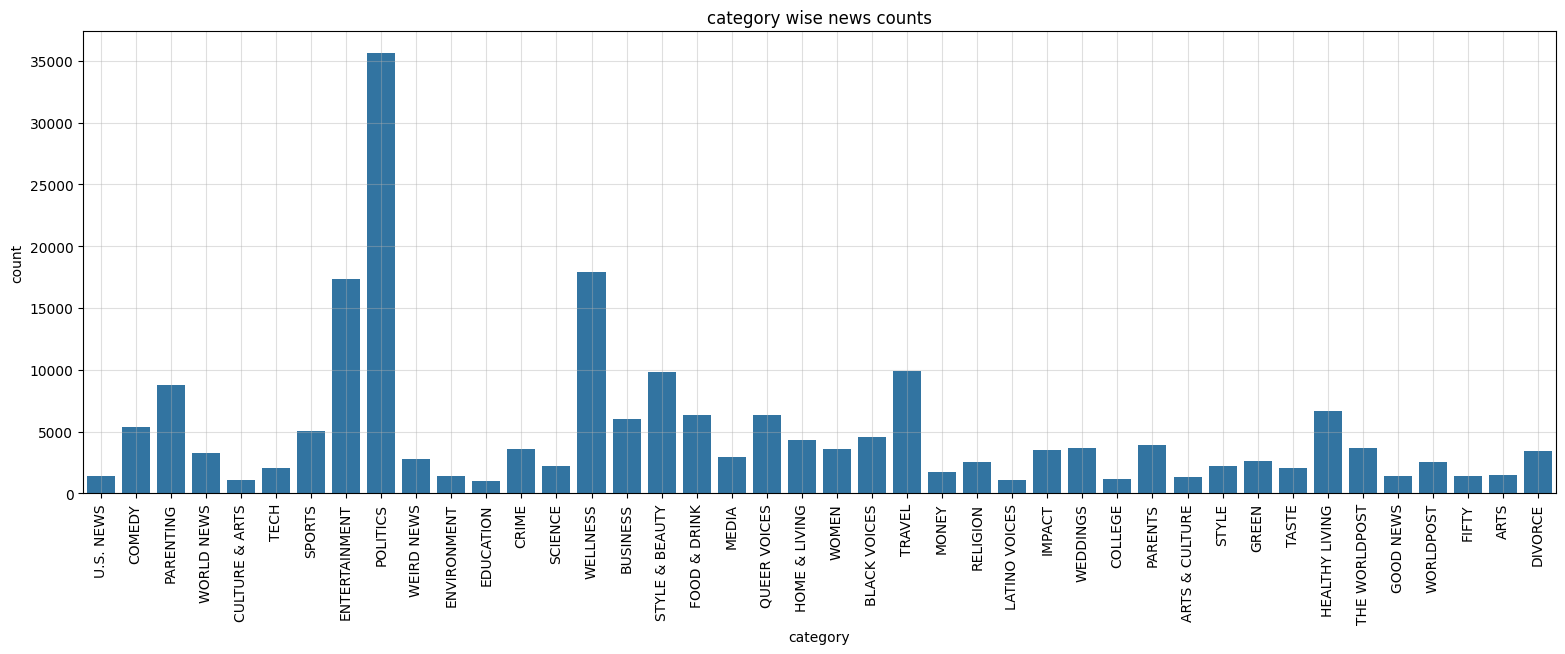

In [ ]:
plt.figure(figsize=(19,6))
sns.countplot(data=df,x='category')
plt.xticks(rotation=90)
plt.title('category wise news counts')
plt.grid(axis='both',alpha=0.4)
plt.show()

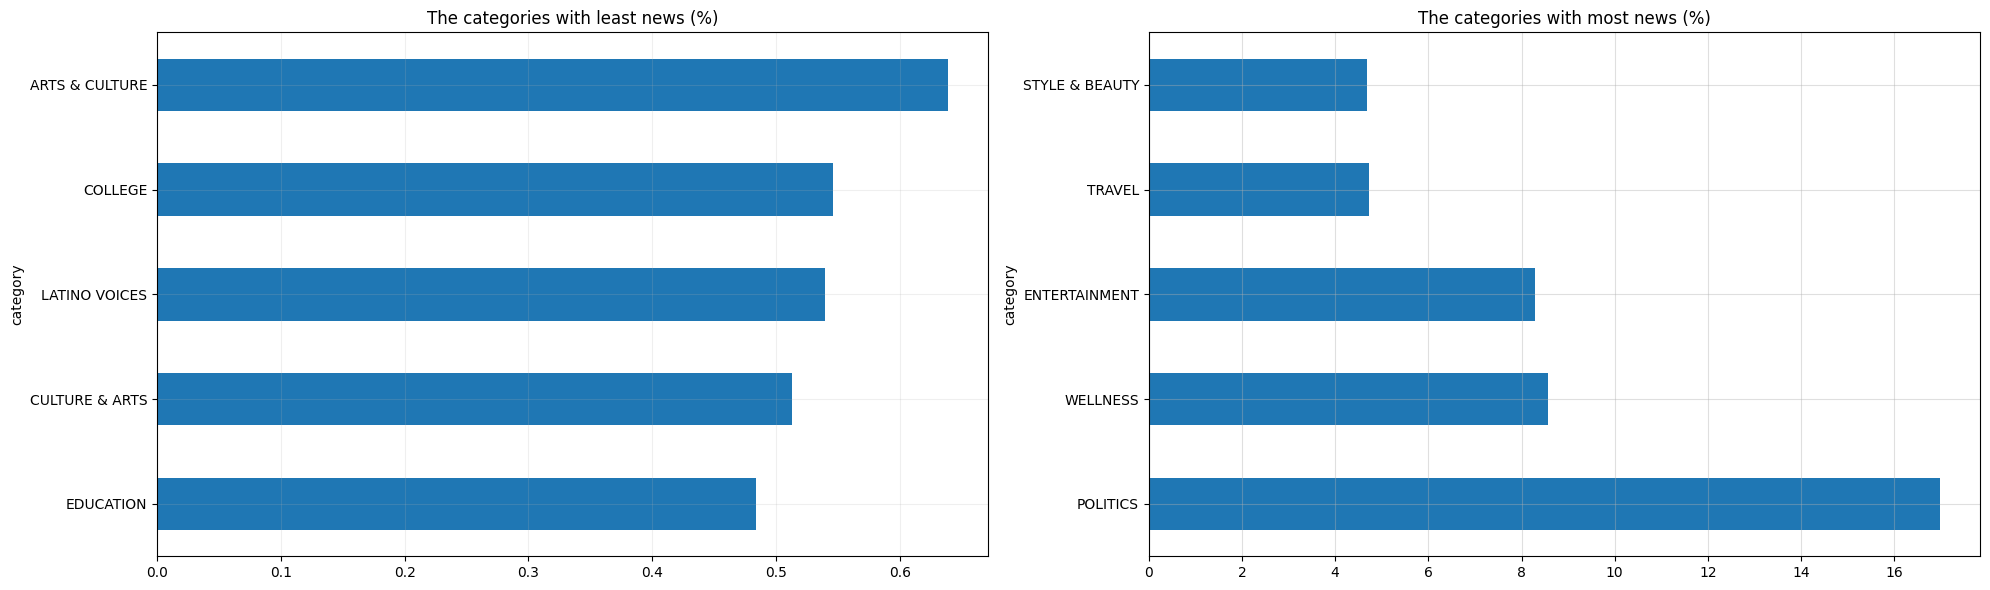

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
(df['category'].value_counts(normalize=True,ascending=True)*100).head(5).plot(kind='barh')
plt.title('The categories with least news (%)')
plt.grid(axis='both',alpha=0.2)


plt.subplot(1,2,2)
(df['category'].value_counts(normalize=True,ascending=False)*100).head(5).plot(kind='barh')
plt.title('The categories with most news (%)')
plt.grid(axis='both',alpha=0.4)

plt.tight_layout()
plt.show()

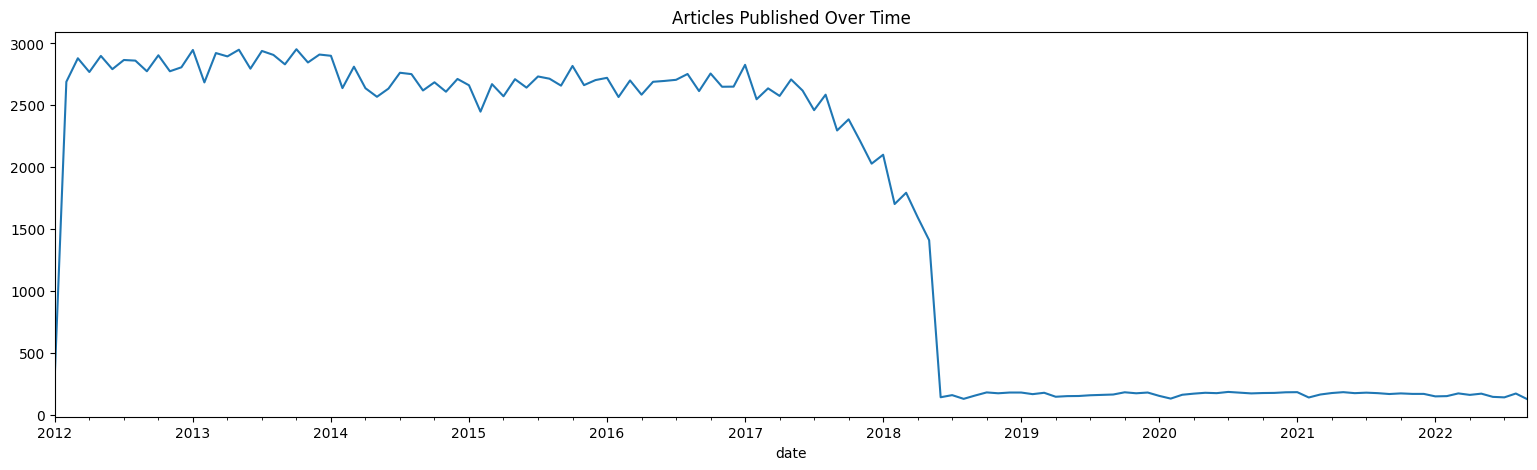

In [ ]:
articles_per_month = df.groupby(df['date'].dt.to_period('M')).size()

articles_per_month.plot(figsize=(19,5))
plt.title("Articles Published Over Time")
plt.show()

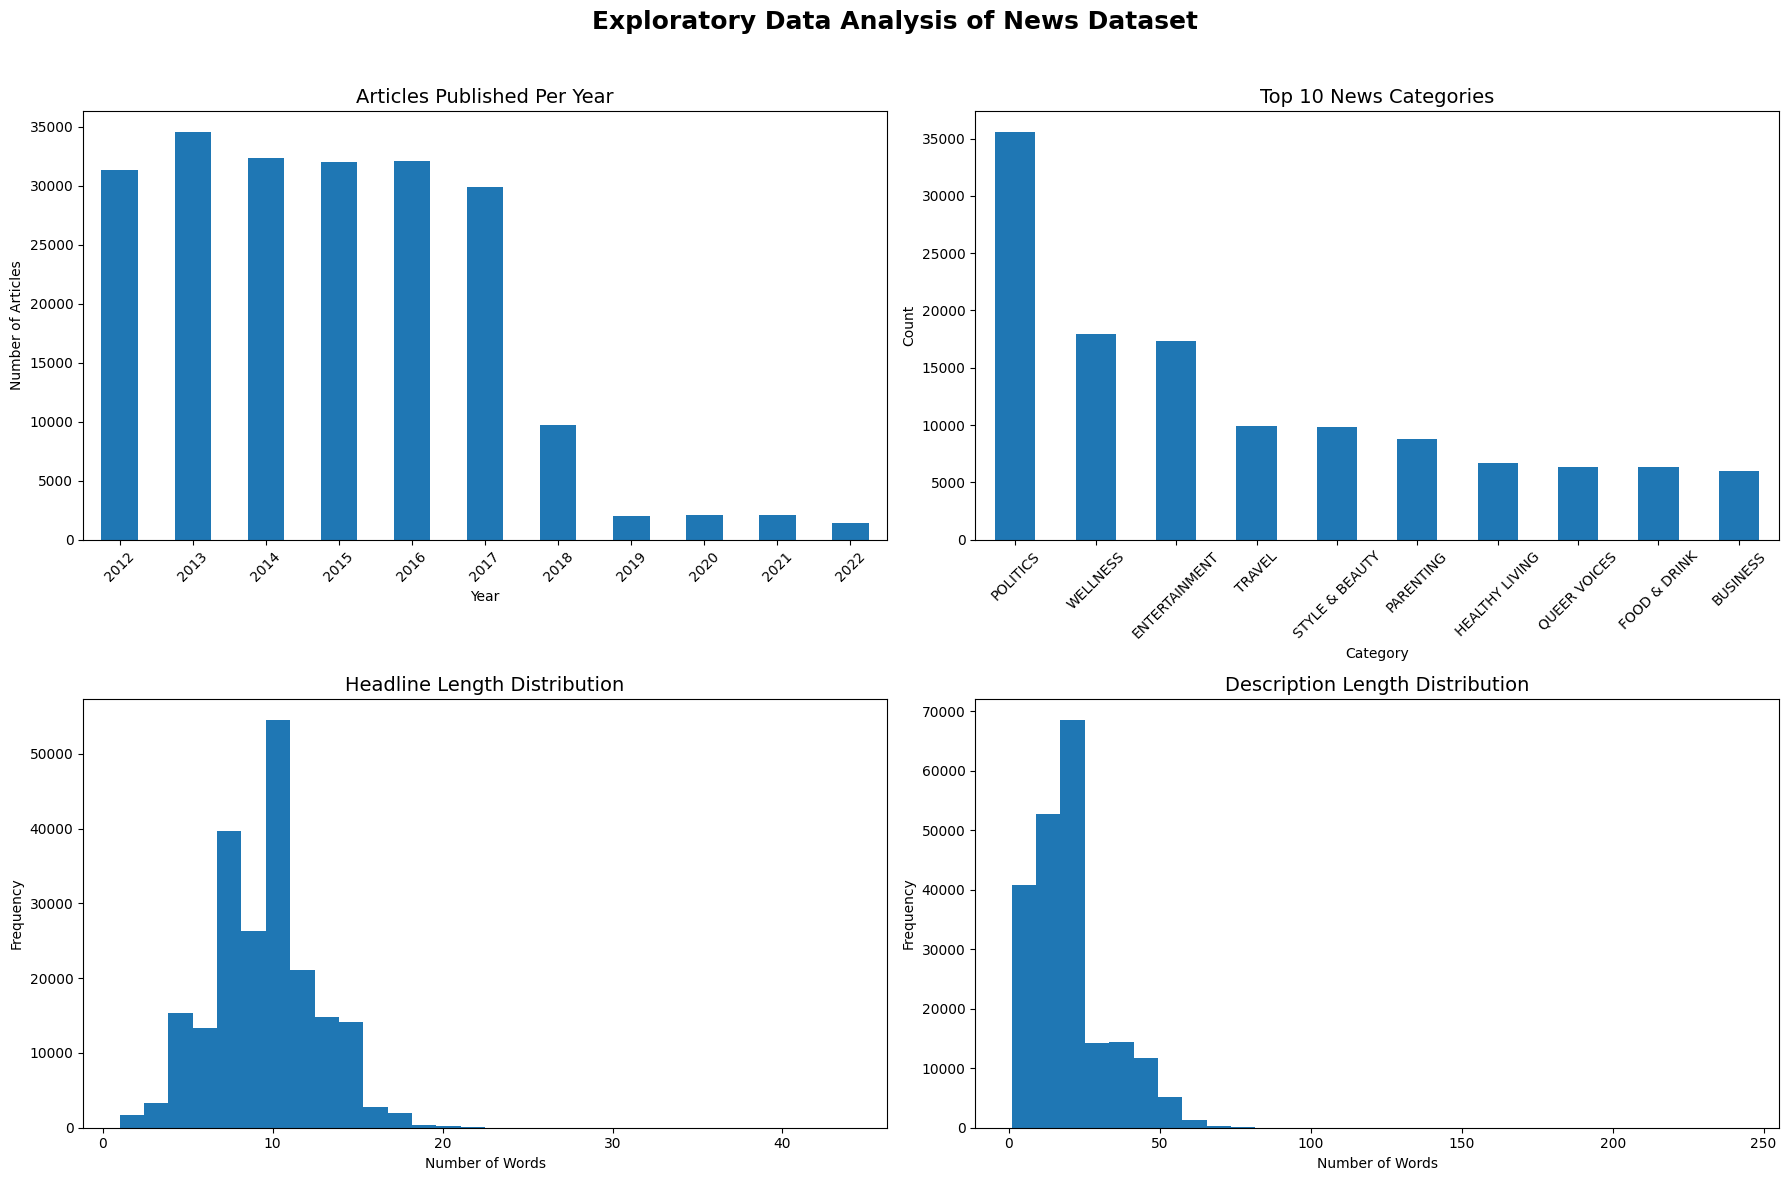

In [ ]:
# Create helper columns
df["year"] = df["date"].dt.year
df["headline_length"] = df["headline"].str.split().str.len()
df["desc_length"] = df["short_description"].fillna("").str.split().str.len()


fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# -------------------------
# 1. Articles Published Per Year
# -------------------------
df["year"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0,0]
)

ax[0,0].set_title("Articles Published Per Year", fontsize=14)
ax[0,0].set_xlabel("Year")
ax[0,0].set_ylabel("Number of Articles")
ax[0,0].tick_params(axis='x', rotation=45)

# -------------------------
# 2. Top 10 Categories
# -------------------------
df["category"].value_counts().head(10).plot(
    kind="bar",
    ax=ax[0,1]
)

ax[0,1].set_title("Top 10 News Categories", fontsize=14)
ax[0,1].set_xlabel("Category")
ax[0,1].set_ylabel("Count")
ax[0,1].tick_params(axis='x', rotation=45)

# -------------------------
# 3. Headline Length Distribution
# -------------------------
ax[1,0].hist(
    df["headline_length"],
    bins=30
)

ax[1,0].set_title("Headline Length Distribution", fontsize=14)
ax[1,0].set_xlabel("Number of Words")
ax[1,0].set_ylabel("Frequency")

# -------------------------
# 4. Description Length Distribution
# -------------------------
ax[1,1].hist(
    df["desc_length"],
    bins=30
)

ax[1,1].set_title("Description Length Distribution", fontsize=14)
ax[1,1].set_xlabel("Number of Words")
ax[1,1].set_ylabel("Frequency")


fig.suptitle(
    "Exploratory Data Analysis of News Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

## 4. Feature Engineering

### 4.1 Combine Headline and Description into a Single Text Field

In [ ]:
df['text'] = df['headline'] + " " + df['short_description']

### 4.2 Text Preprocessing (Optional)

In [ ]:
# from string import punctuation

# def remove_pun(text):
#   return "".join([i for i in text if i not in punctuation])

# df['text'] = df['text'].apply(lambda x: x.lower())
# df['text'] = df['text'].apply(lambda x: remove_pun(x))

## 5. Text Embedding Generation

### 5.1 Sentence Transformer Setup

In [ ]:
pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device="cuda"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 5.2 Generate and Persist Embeddings

In [ ]:
embeddings = model.encode(
    df["text"].fillna("").astype(str).tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/1637 [00:00<?, ?it/s]

In [ ]:
np.save("news_embeddings.npy", embeddings)

In [28]:
embeddings = np.load("/content/drive/MyDrive/news_embeddings.npy")

## 6. Event Clustering

### 6.1 Dimensionality Reduction (UMAP)

In [ ]:
import umap
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=50,
    metric="cosine",
    random_state=42
  )

In [ ]:
reduced_emb = reducer.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 6.2 Clustering (HDBSCAN)

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    metric="euclidean"
)

labels = clusterer.fit_predict(reduced_emb)

In [ ]:
np.save("/content/drive/MyDrive/news_labels.npy", labels)

In [ ]:
labels = np.load("/content/drive/MyDrive/news_labels.npy")

In [ ]:
df['cluster'] = labels

## 7. Cluster Labeling

### 7.1 Keyword Extraction (TF-IDF)

In [ ]:
import nltk
from string import punctuation
from nltk.stem import WordNetLemmatizer

# Download once
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

# Remove punctuation
def remove_pun(text):
    return "".join(char for char in text if char not in punctuation)

# Lemmatize each word
def lemmatize_text(text):
    return " ".join(lemmatizer.lemmatize(word) for word in text.split())

# Preprocessing
df["text"] = df["text"].fillna("")
df["text"] = df["text"].str.lower()
df["text"] = df["text"].apply(remove_pun)
df["text"] = df["text"].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import numpy as np

# Remove HDBSCAN noise
df_cluster = df[df["cluster"] != -1].copy()

# Combine all documents belonging to the same cluster
cluster_docs = (
    df_cluster
    .groupby("cluster")["text"]
    .apply(" ".join)
)

# Count Vectorizer
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,  #word should came atleast two times
    max_df=0.95   #the word should not come more that 95% in doc
)

count_matrix = vectorizer.fit_transform(cluster_docs)

# TF-IDF
transformer = TfidfTransformer()
tfidf = transformer.fit_transform(count_matrix)

# Vocabulary
words = np.array(vectorizer.get_feature_names_out())

# Extract Top 10 Keywords
cluster_keywords = {}

for i, cluster in enumerate(cluster_docs.index):

    scores = tfidf[i].toarray().flatten()

    top_idx = scores.argsort()[-10:][::-1]

    cluster_keywords[cluster] = list(zip(words[top_idx], scores[top_idx]))

# Display Keywords
for cluster, keywords in cluster_keywords.items():
    print(f"\nCluster {cluster}")
    for word, score in keywords:
        print(f"{word:<20} {score:.4f}")    #for better spacing and neat representation



Cluster 0
brilliant succinct   0.2474
fail brighten        0.2474
twitter fail         0.2474
succinct wisdom      0.2474
wisdom week          0.2474
day brilliant        0.2389
lady twitter         0.2323
tweet woman          0.2323
week lady            0.2269
succinct             0.2224

Cluster 1
vintage home         0.3971
ebay                 0.3461
vintage              0.3075
roundup              0.2882
roundup vintage      0.2575
receive ebay         0.2546
ebay roundup         0.2458
mailing list         0.2207
mailing              0.2112
weekly roundup       0.1985

Cluster 2
video week           0.4360
youtube video        0.4143
youtube              0.3316
watch youtube        0.2624
looking popular      0.2624
popular youtube      0.2464
week look            0.2359
look bringing        0.2249
bringing watch       0.2155
week youre           0.1877

Cluster 3
video week           0.4268
youtube video        0.3986
youtube              0.3136
look bringing        0.2614
look

TF-IDF is used because we want the most representative keywords for each cluster, not simply the words that appear the most.

In [ ]:
# Create dictionary: cluster -> "keyword1, keyword2, ..."
cluster_keyword_text = {}

for cluster, keywords in cluster_keywords.items():
    cluster_keyword_text[cluster] = ", ".join(
        [word for word, score in keywords]
    )

# Add new column to the dataframe
df["keywords"] = df["cluster"].map(cluster_keyword_text)

# Noise points (-1) will have NaN. Replace if needed.
df["keywords"] = df["keywords"].fillna("general_news")

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df.shape

(209508, 11)

### 7.2 Representative Headline Extraction (Similarity-Based)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Dictionary to store representative headline for each cluster
cluster_labels = {}

# Ignore HDBSCAN noise cluster (-1)
clusters = sorted(df[df["cluster"] != -1]["cluster"].unique())

for cluster in clusters:

    # Articles belonging to this cluster
    cluster_df = df[df["cluster"] == cluster]

    # Original SBERT embeddings of those articles
    cluster_embeddings = embeddings[cluster_df.index]

    # Compute centroid
    centroid = cluster_embeddings.mean(axis=0)

    # Cosine similarity with centroid
    similarity = cosine_similarity(
        cluster_embeddings,
        centroid.reshape(1, -1)
    ).flatten()

    # Most representative article
    best_idx = similarity.argmax()

    representative_headline = cluster_df.iloc[best_idx]["headline"]

    cluster_labels[cluster] = representative_headline

print(cluster_labels)

{np.int64(0): 'The 20 Funniest Tweets From Women This Week', np.int64(1): 'Weekly Roundup of eBay Vintage Home Finds (PHOTOS)', np.int64(2): 'Watch The Top 9 YouTube Videos Of The Week', np.int64(3): 'Watch The Top 9 YouTube Videos Of The Week', np.int64(4): 'The Funniest Tweets From Women This Week', np.int64(5): 'Weekly Roundup of eBay Vintage Clothing Finds (PHOTOS)', np.int64(6): 'The Weekly Rune: Raidho', np.int64(7): 'Time Out Tip Of The Day: September 29, 2013', np.int64(8): "FEARLESS MEMOIR: 'World's Fair' (Chapter 24)", np.int64(9): 'HuffPost Rise: What You Need To Know On December 23', np.int64(10): 'Weekly Roundup of eBay Vintage Clothing Finds (PHOTOS)', np.int64(11): 'Know Why This Man Was A Weird News Headliner This Week? Take The Fark Weird News Quiz', np.int64(12): 'HuffPost Rise: What You Need To Know On February 23', np.int64(13): 'Stolen Moment Of The Week', np.int64(14): "Henry Louis Gates Jr. Helps Barbara Walters Uncover Her Past On TV Show 'Finding Your Roots' (V

In [ ]:
df["event_label"] = df["cluster"].map(cluster_labels)
df['event_label'] = df['event_label'].fillna('general_news')

In [ ]:
df.to_csv("/content/drive/MyDrive/news_clustered.csv")

## 8. Event Table Construction

In [ ]:
df.head(1)

,link,headline,category,short_description,authors,date,year,headline_length,desc_length,text,cluster,keywords,event_label
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.,"Carla K. Johnson, AP",2022-09-23,2022,11,29,over 4 million american roll up sleeve for omicrontargeted covid booster health expert said it is too early to predict whether demand would match up with the 171 million dos of the new booster the u ordered for the fall,1221,"covid19, coronavirus, covid19 case, coronavirus death, case, virus, death, booster, reported, death toll","Nearly 1,000 People Diagnosed With Coronavirus In U.S."


In [5]:
event_table = (
    df.groupby("cluster").agg(
        representative_headline=("event_label", "first"),
        keywords=("keywords", "first"),
        article_count=("headline", "count"),
        start_date=("date", "min"),
        end_date=("date", "max")
    )
    .reset_index()
)

In [6]:
event_table["duration_days"] = (
    event_table["end_date"] - event_table["start_date"]
).dt.days + 1

In [7]:
event_table = event_table.sort_values("start_date").reset_index(drop=True)

In [8]:
event_table.head()

,cluster,representative_headline,keywords,article_count,start_date,end_date,duration_days
0,-1,general_news,general_news,109842,2012-01-28,2022-09-22,3891
1,415,The Rest They Need: The Role of the Parent in ...,"sleep, pediatric, softie, sleep problem, pedia...",5,2012-01-28,2014-02-25,760
2,3830,IKEA Goes Beyond Meatballs And Futons With Sur...,"ikea, furniture, ikeas, swedish, meatball, mat...",22,2012-01-28,2018-01-28,2193
3,3109,FDIC Ends April 2012 Closing Five More Banks,"fdic, bank, acquirer, closure, 2012, shutter, ...",8,2012-01-28,2012-10-26,273
4,2849,SpaceX Launches Rocket From NASA Pad In Florid...,"spacex, space, space station, astronaut, rocke...",37,2012-01-28,2022-09-20,3889


## 9. Event Analysis & Visualization

In [ ]:
event_table = event_table[event_table["cluster"] != -1].copy()
total_events = event_table.shape[0]
total_articles = event_table["article_count"].sum()
avg_articles = event_table["article_count"].mean()
avg_duration = event_table["duration_days"].mean()
largest_event = event_table.loc[
    event_table["article_count"].idxmax(),
    "representative_headline"
]

print("Total Events :", total_events)
print("Total Articles :", total_articles)
print("Average Articles/Event :", round(avg_articles,2))
print("Average Event Duration :", round(avg_duration,2),"days")
print("Largest Event :", largest_event)

Total Events : 4820
Total Articles : 99666
Average Articles/Event : 20.68
Average Event Duration : 1537.84 days
Largest Event : [WHISPERS] Hey, You Know, Republicans Should Just Fix Obamacare, Call It A Day


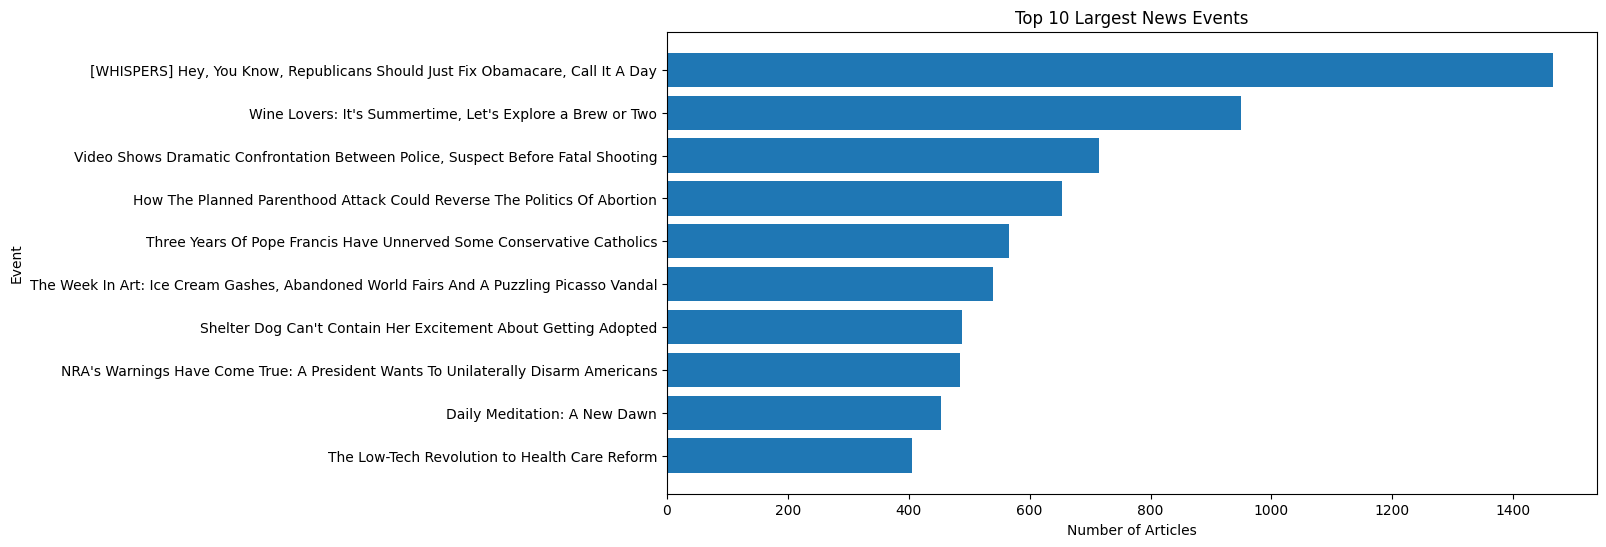

In [ ]:
import matplotlib.pyplot as plt

top10 = (
    event_table
    .nlargest(10,"article_count")
    .sort_values("article_count")
)

plt.figure(figsize=(12,6))
plt.barh(
    top10["representative_headline"],
    top10["article_count"]
)

plt.xlabel("Number of Articles")
plt.ylabel("Event")
plt.title("Top 10 Largest News Events")

plt.show()

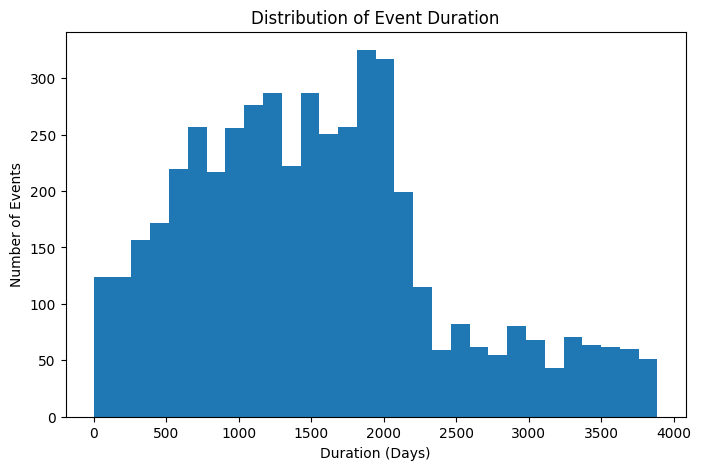

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(event_table["duration_days"],bins=30)

plt.xlabel("Duration (Days)")
plt.ylabel("Number of Events")
plt.title("Distribution of Event Duration")

plt.show()

In [ ]:
event_table.nlargest(
    10,
    "duration_days"
)[[
    "representative_headline",
    "duration_days",
    "article_count"
]]

,representative_headline,duration_days,article_count
4,"SpaceX Launches Rocket From NASA Pad In Florida, Completes Re-landing",3889,37
239,Cat And Bobcat Face Off For Control Of Suburban Feline Kingdom,3884,295
46,U.S. Open Final: Djokovic Beats Federer In First Set,3879,39
25,How the Washington Nationals Won Over a Young Atlanta Braves Fan,3875,285
253,The States With The Cheapest Gas: 24/7 Wall St.,3874,33
72,Bear Spotted Chilling In California Swimming Pool,3872,42
605,Call The United Incident What It Is: Police Violence,3866,36
110,Breastfeeding in Public: Where Do American Moms Really Stand?,3865,274
401,How The Planned Parenthood Attack Could Reverse The Politics Of Abortion,3862,654
656,A Brief History Of Viola Davis’ Inspiring Speeches,3855,12


In [ ]:
from collections import Counter

all_keywords = []

for kws in event_table["keywords"]:
    all_keywords.extend(kws.split(", "))

keyword_freq = Counter(all_keywords)

pd.DataFrame(
    keyword_freq.items(),
    columns=["Keyword","Frequency"]
).sort_values(
    "Frequency",
    ascending=False
).head(20)

,Keyword,Frequency
197,trump,348
271,photo,130
199,donald trump,127
198,donald,118
602,woman,117
...,...,...
553,study,63
682,wedding,62
511,city,62
1267,obama,59


In [ ]:
df['cluster'].value_counts().head(10)

,count
cluster,
-1,109842
1851,1465
3747,949
2661,714
618,654
1655,566
3896,540
4648,488
2610,484


In [ ]:
df.head(1)

,link,headline,category,short_description,authors,date,year,headline_length,desc_length,text,cluster,keywords,event_label
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.,"Carla K. Johnson, AP",2022-09-23,2022,11,29,over 4 million american roll up sleeve for omicrontargeted covid booster health expert said it is too early to predict whether demand would match up with the 171 million dos of the new booster the u ordered for the fall,1221,"covid19, coronavirus, covid19 case, coronavirus death, case, virus, death, booster, reported, death toll","Nearly 1,000 People Diagnosed With Coronavirus In U.S."


In [ ]:
monthly_counts = (
    df[df['cluster'] != -1]
    .groupby('event_label')
    .resample('ME', on='date')
    .size()
    .reset_index(name='article_count')
)

In [ ]:
monthly_counts_pivot = monthly_counts.pivot_table(values='article_count', columns='date', index='event_label').fillna(0)
monthly_counts_pivot['total_articles'] = monthly_counts_pivot.sum(axis=1)

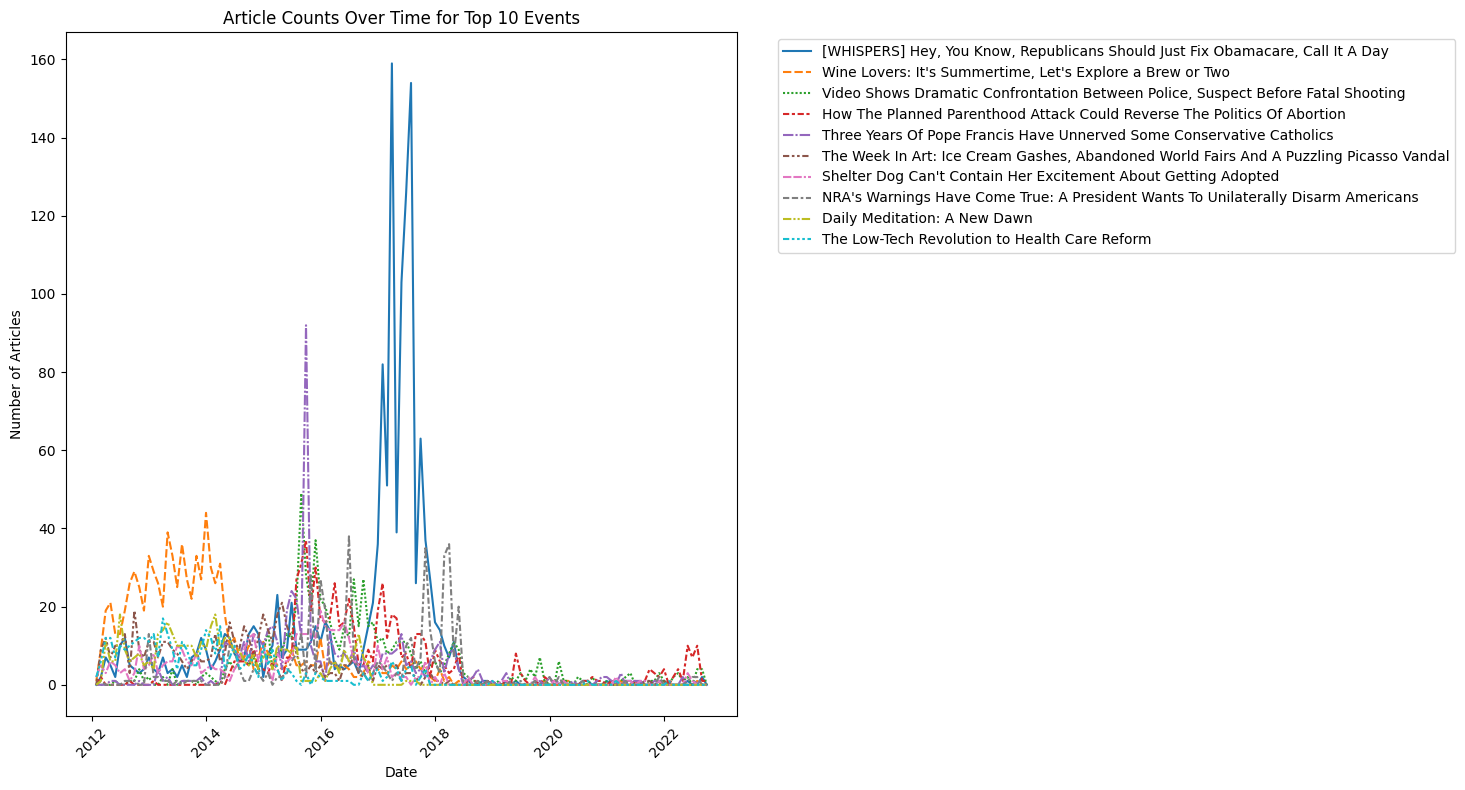

In [ ]:
# Get top 10 events by total articles
top10 = monthly_counts_pivot.sort_values('total_articles', ascending=False).head(10)

# Drop the total column for plotting the timeline
plot_data = top10.drop(columns=['total_articles']).transpose()

plt.figure(figsize=(15, 8))
sns.lineplot(data=plot_data)
plt.title('Article Counts Over Time for Top 10 Events')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
cluster_sizes = (
    df[df["cluster"] != -1]
    .groupby("cluster")
    .size()
    .sort_values(ascending=False)
)

cluster_sizes.describe()

,0
count,4820.000000
mean,20.677593
std,45.156822
min,4.000000
25%,6.000000
50%,10.000000
75%,19.000000
max,1465.000000


In [ ]:
df.head(1)

,link,headline,category,short_description,authors,date,year,headline_length,desc_length,text,cluster,keywords,event_label
0,https://www.huffpost.com/entry/covid-boosters-uptake-us_n_632d719ee4b087fae6feaac9,Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters,U.S. NEWS,Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.,"Carla K. Johnson, AP",2022-09-23,2022,11,29,over 4 million american roll up sleeve for omicrontargeted covid booster health expert said it is too early to predict whether demand would match up with the 171 million dos of the new booster the u ordered for the fall,1221,"covid19, coronavirus, covid19 case, coronavirus death, case, virus, death, booster, reported, death toll","Nearly 1,000 People Diagnosed With Coronavirus In U.S."


## 10. Automated Event Summarization

### 10.1 Summarization Using an LLM (Google Gemini)

In [ ]:
pip install -q google-genai

In [ ]:
from google import genai
from google.genai import types
import json
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
client = genai.Client(api_key="YOUR_API_KEY")

In [ ]:
top_articles = {}

clusters = sorted(df[df["cluster"] != -1]["cluster"].unique())

for cluster in clusters:

    cluster_df = df[df["cluster"] == cluster]

    cluster_embeddings = embeddings[cluster_df.index]

    centroid = cluster_embeddings.mean(axis=0)

    similarity = cosine_similarity(
        cluster_embeddings,
        centroid.reshape(1, -1)
    ).flatten()

    top_idx = similarity.argsort()[-5:][::-1]

    top_articles[cluster] = cluster_df.iloc[top_idx]

In [ ]:
top_articles

In [ ]:
event_schema = {
    "type": "object",
    "properties": {
        "event_title": {
            "type": "string"
        },
        "summary": {
            "type": "string"
        },
        "timeline": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "date": {"type": "string"},
                    "event": {"type": "string"}
                },
                "required": ["date", "event"]
            }
        },
        "key_people": {
            "type": "array",
            "items": {"type": "string"}
        },
        "organizations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "locations": {
            "type": "array",
            "items": {"type": "string"}
        },
        "authors": {
            "type": "array",
            "items": {"type": "string"}
        },
        "categories": {
            "type": "array",
            "items": {"type": "string"}
        },
        "keywords": {
            "type": "array",
            "items": {"type": "string"}
        },
        "references": {
            "type": "array",
            "items": {"type": "string"}
        }
    },
    "required": [
        "event_title",
        "summary",
        "timeline",
        "key_people",
        "organizations",
        "locations",
        "authors",
        "categories",
        "keywords",
        "references"
    ]
}

In [ ]:
def generate_summary(prompt):

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt,
        config={
            "response_mime_type": "application/json",
            "response_json_schema": event_schema
        }
    )

    print(response.text)

    return json.loads(response.text)

In [ ]:
def build_prompt(event_row, representative_articles):

    prompt = f"""
You are a professional news analyst.

The following articles belong to the same news cluster.

Your task is to create a factual event report based ONLY
on the information provided in these articles.

EVENT INFORMATION
-----------------

Representative headline:
{event_row['representative_headline']}

Keywords:
{event_row['keywords']}

Start date:
{event_row['start_date']}

End date:
{event_row['end_date']}

Article count:
{event_row['article_count']}

ARTICLES
--------

"""

    for i, (_, row) in enumerate(
        representative_articles.iterrows(),
        start=1
    ):

        prompt += f"""

ARTICLE {i}

Headline:
{row['headline']}

Publication date:
{row['date']}

Author:
{row['authors']}

Category:
{row['category']}

Description:
{row['short_description']}

Reference URL:
{row['link']}

"""

    prompt += """

TASK
----

Create an event report.

Summary requirements:
- Write 3-5 sentences.
- Explain the main event.
- Explain how the event developed over time.
- Mention important developments in chronological order.
- Use only facts supported by the supplied articles.
- Do not invent information.

Timeline requirements:
- Extract important developments from the supplied articles.
- Use the article publication date when reporting the development.
- Keep events in chronological order.

People:
- Include only people explicitly mentioned in the articles.

Organizations:
- Include only organizations explicitly mentioned.

Locations:
- Include only locations explicitly mentioned.

Authors:
- Include the authors provided in the articles.

References:
- Include the original article URLs provided in the data.

If information is unavailable, return an empty list.
"""

    return prompt

In [ ]:
cluster = 415

event = event_table[
    event_table["cluster"] == cluster
].iloc[0]

articles = top_articles[cluster]

prompt = build_prompt(
    event,
    articles
)

report = generate_summary(prompt)

report

{"event_title":"Pediatric Sleep Guidance and Parental Roles","summary":"Between January 2012 and February 2014, various medical perspectives and scientific reports addressed pediatric sleep habits, co-sleeping risks, and the parental role in children's rest. In early 2012, pediatricians offered insights on sleep guidance and medical practices, while subsequent coverage highlighted the American Academy of Pediatrics' recommendation favoring room sharing over bed-sharing with infants. By May 2013, reporting focused on evidence indicating that infant nighttime sleep habits are largely genetic. In February 2014, sleep experts emphasized that a major initial challenge for physicians handling pediatric sleep problems is determining whether the issue stems from the child, parent, or family.","timeline":[{"date":"2012-01-28","event":"Pediatrician Claire McCarthy reflected on pediatric sleep practices, noting her compassionate approach as a sleep softie."},{"date":"2012-03-16","event":"Drs. Mar

{'event_title': 'Pediatric Sleep Guidance and Parental Roles',
 'summary': "Between January 2012 and February 2014, various medical perspectives and scientific reports addressed pediatric sleep habits, co-sleeping risks, and the parental role in children's rest. In early 2012, pediatricians offered insights on sleep guidance and medical practices, while subsequent coverage highlighted the American Academy of Pediatrics' recommendation favoring room sharing over bed-sharing with infants. By May 2013, reporting focused on evidence indicating that infant nighttime sleep habits are largely genetic. In February 2014, sleep experts emphasized that a major initial challenge for physicians handling pediatric sleep problems is determining whether the issue stems from the child, parent, or family.",
 'timeline': [{'date': '2012-01-28',
   'event': 'Pediatrician Claire McCarthy reflected on pediatric sleep practices, noting her compassionate approach as a sleep softie.'},
  {'date': '2012-03-16',

### 10.2 Summarization Using a Pretrained BART Transformer

In [ ]:
!pip install -q transformers sentencepiece

In [ ]:
# from transformers import BartForConditionalGeneration, BartTokenizer
# import torch

# device = "cuda" if torch.cuda.is_available() else "cpu"

# model_name = "facebook/bart-large-cnn"
# model = BartForConditionalGeneration.from_pretrained(model_name).to(device)
# tokenizer = BartTokenizer.from_pretrained(model_name)

# def summarizer(text, **kwargs):
#     # Accept keyword arguments like max_length, min_length, etc.
#     inputs = tokenizer([text], max_length=1024, return_tensors="pt", truncation=True).to(device)

#     # Default generation parameters if not provided
#     gen_kwargs = {
#         "num_beams": 4,
#         "max_length": 150,
#         "early_stopping": True
#     }
#     gen_kwargs.update(kwargs)

#     summary_ids = model.generate(inputs["input_ids"], **gen_kwargs)
#     return [{"summary_text": tokenizer.decode(g, skip_special_tokens=True, clean_up_tokenization_spaces=False)} for g in summary_ids]

# print(f"Model loaded on: {device.upper()}")



# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity

# top_articles = {}

# clusters = sorted(
#     df[df["cluster"] != -1]["cluster"].unique()
# )

# for cluster in clusters:

#     cluster_df = df[
#         df["cluster"] == cluster
#     ].copy()

#     # SBERT embeddings for this cluster
#     cluster_embeddings = embeddings[cluster_df.index]

#     # Cluster centroid
#     centroid = cluster_embeddings.mean(axis=0)

#     # Similarity to centroid
#     similarity = cosine_similarity(
#         cluster_embeddings,
#         centroid.reshape(1, -1)
#     ).flatten()

#     # Take top 5 representative articles
#     top_idx = similarity.argsort()[-5:][::-1]

#     top_articles[cluster] = cluster_df.iloc[top_idx]


# def prepare_article_text(articles):

#     texts = []

#     # Sort chronologically
#     articles = articles.sort_values("date")

#     for _, row in articles.iterrows():

#         headline = str(row["headline"])
#         description = str(row["short_description"])

#         text = (
#             f"On {row['date'].strftime('%Y-%m-%d')}, "
#             f"{headline}. "
#             f"{description}"
#         )

#         texts.append(text)

#     return " ".join(texts)

# def prepare_article_text(articles):

#     texts = []

#     # Sort chronologically
#     articles = articles.sort_values("date")

#     for _, row in articles.iterrows():

#         headline = str(row["headline"])
#         description = str(row["short_description"])

#         text = (
#             f"On {row['date'].strftime('%Y-%m-%d')}, "
#             f"{headline}. "
#             f"{description}"
#         )

#         texts.append(text)

#     return " ".join(texts)




# cluster = 415

# articles = top_articles[cluster]

# source_text = prepare_article_text(articles)

# print(source_text)



# summary_result = summarizer(
#     source_text,
#     max_length=150,
#     min_length=50,
#     do_sample=False
# )

# summary = summary_result[0]["summary_text"]

# print(summary)

Workflow : Take all articles belonging to one cluster → calculate cosine similarity with the cluster centroid → select the top 5 most representative articles → arrange those 5 articles by date → combine their headlines and descriptions → send the text to BART → generate one final natural event summary.

In [9]:
import torch
from transformers import (
    BartForConditionalGeneration,
    BartTokenizer
)


# ============================================================
# 1. LOAD BART
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "facebook/bart-large-cnn"

model = BartForConditionalGeneration.from_pretrained(
    model_name
).to(device)

tokenizer = BartTokenizer.from_pretrained(
    model_name
)

model.eval()

print(f"Model loaded on: {device.upper()}")


# ============================================================
# 2. BART SUMMARIZER
# ============================================================

def summarizer(
    text,
    max_length=150,
    min_length=50
):

    inputs = tokenizer(
        text,
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            num_beams=4,
            max_length=max_length,
            min_length=min_length,
            do_sample=False,
            early_stopping=True
        )

    summary = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )

    return summary

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded on: CUDA


In [10]:
def create_cluster_chunks(
    cluster,
    max_tokens=900
):

    # Get ALL articles from cluster
    articles = df[
        df["cluster"] == cluster
    ].copy()

    # Sort chronologically
    articles = articles.sort_values(
        "date"
    )

    chunks = []

    current_articles = []
    current_tokens = 0

    for _, row in articles.iterrows():

        date = row["date"].strftime(
            "%Y-%m-%d"
        )

        headline = str(
            row["headline"]
        )

        description = str(
            row["short_description"]
        )

        article_text = (
            f"On {date}, "
            f"{headline}. "
            f"{description}"
        )

        # Count BART tokens
        article_tokens = len(
            tokenizer.encode(
                article_text,
                add_special_tokens=False
            )
        )

        # Create new chunk if limit reached
        if (
            current_tokens + article_tokens
            > max_tokens
            and current_articles
        ):

            chunks.append(
                " ".join(current_articles)
            )

            current_articles = []
            current_tokens = 0

        current_articles.append(
            article_text
        )

        current_tokens += article_tokens

    # Add final chunk
    if current_articles:

        chunks.append(
            " ".join(current_articles)
        )

    return chunks

In [11]:
def generate_event_summary(cluster):

    # Ignore HDBSCAN noise
    if cluster == -1:

        return (
            "General news articles "
            "not assigned to a specific event."
        )

    # -----------------------------------------
    # STEP 1: Create chunks
    # -----------------------------------------

    chunks = create_cluster_chunks(
        cluster,
        max_tokens=900
    )

    print(
        f"Cluster {cluster}: "
        f"{len(chunks)} chunks"
    )

    # -----------------------------------------
    # STEP 2: Summarize each chunk
    # -----------------------------------------

    chunk_summaries = []

    for i, chunk in enumerate(chunks):

        try:

            summary = summarizer(
                chunk,
                max_length=150,
                min_length=50
            )

            chunk_summaries.append(
                summary
            )

            print(
                f"Chunk {i + 1}/{len(chunks)} completed"
            )

        except Exception as e:

            print(
                f"Error in chunk {i + 1}: {e}"
            )

    # -----------------------------------------
    # STEP 3: Check results
    # -----------------------------------------

    if not chunk_summaries:

        return ""

    # -----------------------------------------
    # STEP 4: Combine chunk summaries
    # -----------------------------------------

    combined_summary = " ".join(
        chunk_summaries
    )

    # -----------------------------------------
    # STEP 5: Final BART summarization
    # -----------------------------------------

    final_summary = summarizer(
        combined_summary,
        max_length=200,
        min_length=60
    )

    return final_summary

**WorkFlow** : Take all articles belonging to one cluster → arrange them by date → split them into BART-sized chunks → summarize each chunk → combine those summaries → summarize again to get one final event summary.

                 CLUSTER
                    │
             100s of articles
                    │
                    ▼
               BART chunks
                    │
        ┌───────────┼───────────┐
        ▼           ▼           ▼
     Summary 1   Summary 2   Summary 3
        │           │           │
        └───────────┼───────────┘
                    ▼
             Combined summaries
                    │
                    ▼
               BART again
                    │
                    ▼
          FINAL EVENT SUMMARY

In [12]:
cluster = 415

summary = generate_event_summary(
    cluster
)

print("\nFINAL EVENT SUMMARY:\n")
print(summary)

Cluster 415: 1 chunks


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Chunk 1/1 completed

FINAL EVENT SUMMARY:

The American Academy of Pediatrics recommends room sharing with infants, but not bed-sharing. One of the first challenges for a physician faced with a pediatric sleep problem is to identify who actually has the problem. The parent, the patient, or another family member may be to blame for a child's sleep problems.


## 11. Final Output Generation & Export

In [13]:
top_100 = (
    event_table[
        event_table["cluster"] != -1
    ]
    .nlargest(
        100,
        "article_count"
    )
    .copy()
)

In [15]:
from tqdm.auto import tqdm

top_100["summary"] = ""

for idx, row in tqdm(
    top_100.iterrows(),
    total=len(top_100)
):

    cluster = row["cluster"]

    try:

        summary = generate_event_summary(
            cluster
        )

        top_100.at[
            idx,
            "summary"
        ] = summary

    except Exception as e:

        print(
            f"Error in cluster {cluster}: {e}"
        )

        top_100.at[
            idx,
            "summary"
        ] = ""

  0%|          | 0/100 [00:00<?, ?it/s]

Cluster 1851: 71 chunks
Chunk 1/71 completed
Chunk 2/71 completed
Chunk 3/71 completed
Chunk 4/71 completed
Chunk 5/71 completed
Chunk 6/71 completed
Chunk 7/71 completed
Chunk 8/71 completed
Chunk 9/71 completed
Chunk 10/71 completed
Chunk 11/71 completed
Chunk 12/71 completed
Chunk 13/71 completed
Chunk 14/71 completed
Chunk 15/71 completed
Chunk 16/71 completed
Chunk 17/71 completed
Chunk 18/71 completed
Chunk 19/71 completed
Chunk 20/71 completed
Chunk 21/71 completed
Chunk 22/71 completed
Chunk 23/71 completed
Chunk 24/71 completed
Chunk 25/71 completed
Chunk 26/71 completed
Chunk 27/71 completed
Chunk 28/71 completed
Chunk 29/71 completed
Chunk 30/71 completed
Chunk 31/71 completed
Chunk 32/71 completed
Chunk 33/71 completed
Chunk 34/71 completed
Chunk 35/71 completed
Chunk 36/71 completed
Chunk 37/71 completed
Chunk 38/71 completed
Chunk 39/71 completed
Chunk 40/71 completed
Chunk 41/71 completed
Chunk 42/71 completed
Chunk 43/71 completed
Chunk 44/71 completed
Chunk 45/71 compl

In [16]:
top_100["authors"] = None
top_100["references"] = None

for idx, row in top_100.iterrows():

    cluster = row["cluster"]

    cluster_df = df[
        df["cluster"] == cluster
    ]

    # Authors
    authors = (
        cluster_df["authors"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    authors = (
        authors[
            authors != ""
        ]
        .unique()
        .tolist()
    )

    # References
    references = (
        cluster_df["link"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    references = (
        references[
            references != ""
        ]
        .unique()
        .tolist()
    )

    top_100.at[
        idx,
        "authors"
    ] = authors

    top_100.at[
        idx,
        "references"
    ] = references

In [18]:
top_100.to_csv("/content/drive/MyDrive/top100_news_clustered.csv")

In [24]:
top_100.head()

,cluster,representative_headline,keywords,article_count,start_date,end_date,duration_days,summary,authors,references
547,1851,"[WHISPERS] Hey, You Know, Republicans Should J...","obamacare, health care, health, care, insuranc...",1465,2012-02-20,2022-08-22,3837,Don't expect the cost of health care to get ch...,"[Jonathan Cohn, Kevin Robillard, SAM METZ, AP,...",[https://www.huffpost.com/entry/child-care-pai...
76,3747,"Wine Lovers: It's Summertime, Let's Explore a ...","wine, beer, cocktail, drink, bottle, whiskey, ...",949,2012-01-30,2022-07-08,3813,"Summer comes to an official end today, and wit...","[Julie Kendrick, Caroline Bologna, David Moye,...",[https://www.huffpost.com/entry/how-to-make-a-...
1641,2661,Video Shows Dramatic Confrontation Between Pol...,"police, shooting, officer, shot, suspect, cop,...",714,2012-05-27,2022-08-15,3733,The Best Idea for 2014 was requiring police to...,"[Unknown, Ben Blanchet, Elyse Wanshel, Phillip...",[https://www.huffpost.com/entry/six-flags-grea...
401,618,How The Planned Parenthood Attack Could Revers...,"abortion, planned parenthood, parenthood, plan...",654,2012-02-12,2022-09-08,3862,"In the United Sates, one out of every three wo...","[Jonathan Cohn, Dave Kolpack, AP, Thomas Beaum...",[https://www.huffpost.com/entry/michigan-abort...
1403,1655,Three Years Of Pope Francis Have Unnerved Some...,"pope, francis, pope francis, catholic, vatican...",566,2012-04-29,2022-07-04,3719,The Pope underwent surgery a few months ago to...,"[Jazmin Tolliver, FRANCES D'EMILIO, AP, Nicole...",[https://www.huffpost.com/entry/pope-francis-c...
